In [17]:
import os
import urllib
from pathlib import Path
import cv2
import pylupnt as pnt
import numpy as np
import numpy.linalg as LA
import pandas as pd
from PIL import Image
import spiceypy as spice
import plotly.graph_objects as go

from matplotlib import pyplot as plt
from scipy.spatial.transform import Rotation as R
from astropy.coordinates import cartesian_to_spherical, spherical_to_cartesian
from pylupnt.crater_detection.common.camera import Camera
from pylupnt.crater_detection.common.coordinates import ENU_system, nadir_attitude

from pylupnt.crater_detection.common.robbins import (
    extract_robbins_dataset,
    load_craters,
)
from pylupnt.crater_detection.matching.projective_invariants import (
    conic_matrix,
    matrix_adjugate,
)
import pylupnt.crater_detection.common.constants as const
from pylupnt.crater_detection.common.conics import *

In [36]:
# Image setup:
fov = 45
N = (1024, 1024)
renderer = pnt.render.Blender()
renderer.SCENE["fov"] = fov
renderer.ENGINE = renderer.EEVEE
renderer.SCENE["resx"] = N[0]
renderer.SCENE["resy"] = N[1]
renderer.SCENE["rendSamples"] = 64
renderer.update_scene()

t_tai = pnt.SpiceInterface.string_to_tai("2020-05-15T00:00:00")
r_sun_mi = pnt.SpiceInterface.get_body_pos(pnt.SUN, t_tai, pnt.MI, pnt.MOON, "NONE")[:3]

Read blend: "/Users/guillemcv/Development/NavLab/LuPNT/data/surface/Moon.blend"


In [37]:
# The following extracts all craters with the given parameters and returns their lat, long, psi (angle) in radians, and
# major and minor axis in km.
lat, lon, major, minor, psi, crater_id = extract_robbins_dataset(
    load_craters(
        pnt.utils.find_file("lunar_crater_database_robbins_2018.csv"),
        diamlims=[20, 250],
        ellipse_limit=1.4,
    )
)

In [38]:
### POSITION CAMERA
height = 1000
dist = pnt.R_MOON + height

p_Mi = np.array(spherical_to_cartesian(pnt.R_MOON, lat, lon)).T[:, :, None]
r_M = np.array(spherical_to_cartesian(dist, np.radians(-43.31), np.radians(-11.36)))[
    :, None
]
dist = height / np.cos(np.radians(fov / 2) * np.sqrt(2) * 1.5)
visible = (np.sqrt(np.sum(np.square(p_Mi - r_M), axis=1)) < dist).ravel()
p_Mi = p_Mi[visible]
r_M

array([[ 1952.85443801],
       [ -392.34594634],
       [-1877.7068361 ]])

In [39]:
r_cam_pa = r_M.ravel()
# r_geo = np.array([-71.50, 91.31, 500])
# r_geo[:2] = np.deg2rad(r_geo[:2])
# r_cam_pa = pnt.geographical_to_cartesian(r_geo, pnt.R_MOON)
r_sun_pa = pnt.FrameConverter.convert(t_tai, r_sun_mi, pnt.MI, pnt.PA)
X_ax_cam, Y_ax_cam, Z_ax_cam = nadir_attitude(r_cam_pa[:, None])
T_CM = np.concatenate((X_ax_cam, Y_ax_cam, Z_ax_cam), axis=-1)
R_pa2cam = T_CM.T

renderer.render(r_cam_pa, R_pa2cam, r_sun_pa, "./tmp.png", frame="OpenCV")
im = Image.open("./tmp.png")
im.show()

Fra:0 Mem:572.75M (Peak 572.75M) | Time:00:01.01 | Syncing Sun
Fra:0 Mem:572.75M (Peak 572.75M) | Time:00:01.01 | Syncing Camera
Fra:0 Mem:572.75M (Peak 572.75M) | Time:00:01.01 | Syncing Moon
Fra:0 Mem:1396.99M (Peak 1596.77M) | Time:00:05.23 | Rendering 1 / 32 samples
Fra:0 Mem:1367.01M (Peak 1596.77M) | Time:00:05.47 | Rendering 26 / 32 samples
Fra:0 Mem:1367.08M (Peak 1596.77M) | Time:00:05.47 | Rendering 32 / 32 samples
Saved: 'tmp.png'
Time: 00:05.61 (Saving: 00:00.03)



In [40]:
fig = go.Figure()
r1 = r_cam_pa / LA.norm(r_cam_pa)
r2 = r_sun_pa / LA.norm(r_sun_pa)
fig.add_scatter3d(
    x=[0, r1[0]], y=[0, r1[1]], z=[0, r1[2]], mode="lines+markers", marker=dict(size=10)
)
fig.add_scatter3d(
    x=[0, r2[0]], y=[0, r2[1]], z=[0, r2[2]], mode="lines+markers", marker=dict(size=10)
)
pnt.plot.plot_frame(fig, r1, R_pa2cam, length_scale=0.5, tip_scale=0.2)
fig.show()

### Mathematical Representation of a Crater
Pages 20 - 25 from [Christian, J. A., Derksen, H., & Watkins, R. (2020). Lunar Crater Identification in Digital Images](http://arxiv.org/abs/2009.01228)

#### Convert coordinates to 3D selenographic position
`load_robbins_dataset` extracts all craters with the given parameters and returns their lat, long, psi (angle) in radians, and
major and minor axis in kms.
Filter dataset using latitude & longitude limits using `latlims` and `longlims` parameters.

3D selenographic position is determined using their latitude $\varphi$ & longitude $\lambda$ along with distance
from center $\rho$:

$\rho_i \begin{bmatrix}
\cos\varphi_i\cos\lambda_i \\
\cos\varphi_i\sin\lambda_i \\
\sin\varphi_i
\end{bmatrix}$,

#### Define local ENU coordinate system per crater
$ \mathbf{u}_i = \frac{\mathbf{p}^{(c)}_{M_i}}{||\mathbf{p}^{(c)}_{M_i}||} $,
$ \mathbf{e}_i = \frac{\mathbf{k} \times \mathbf{u}_i}{|| \mathbf{k} \times \mathbf{u}_i ||} $,
$ \mathbf{n}_i = \frac{\mathbf{u}_i \times \mathbf{e}_i}{|| \mathbf{u}_i \times \mathbf{e}_i ||} $,

with $ k = \begin{bmatrix} 0 & 0 & 1 \end{bmatrix}^T $,

results in attitude transformation matrix

$ T^{E_i}_M = \begin{bmatrix} \mathbf{e}_i & \mathbf{n}_i & \mathbf{u}_i \end{bmatrix} $

In [41]:
T_EM = np.concatenate(ENU_system(p_Mi), axis=-1)

#### Define relation between point in 2D ellipse plane and 3D selenographic frame

$ H_{M_i} = \begin{bmatrix}
             T^{E_i}_M \mathbf{S} &  \mathbf{p}^{(c)}_{M_i}
           \end{bmatrix} $

$ \mathbf{S} = \begin{bmatrix}
                    \mathbf{I}_{2\times2} \\
                    \mathbf{0}_{1\times2}
                \end{bmatrix}
$

In [42]:
S = np.concatenate((np.identity(2), np.zeros((1, 2))), axis=0)
H_Mi = np.concatenate((T_EM @ S, p_Mi), axis=-1)

### Homography and Action of a Projective Camera on a Crater Disk Quadric

#### Define camera calibration matrix

The conversion between image plane coordinates ($\mathbf{\bar{x}}_C$) and digital image pixel coordinates
($\mathbf{\bar{u}}_C$) is described the following affine transformation:

$ \mathbf{K} = \begin{bmatrix}
    d_x & \alpha & u_p \\
    0   & d_y    & v_p \\
    0   & 0      & 1
\end{bmatrix} $,

$ \mathbf{\bar{u}}_C = \mathbf{K} \mathbf{\bar{x}}_C$

In [43]:
f_x = (N[0] / 2) / np.tan(np.radians(fov) / 2)
f_y = (N[1] / 2) / np.tan(np.radians(fov) / 2)

K = np.array([[f_x, 0, N[0] / 2], [0, f_y, N[1] / 2], [0, 0, 1]])

Using camera position in camera reference frame $C$  ($\mathbf{r }_C$) and the camera attitude $\mathbf{T}^M_C$ the camera projection matrix is as follows:

$ \mathbf{P}^M_C = \mathbf{K} \begin{bmatrix} \mathbf{T}^M_C & -r_C \end{bmatrix}$

With this, the homography to project the crater's disk quadric into its apparent ellipse in the image plane is found:

$ \mathbf{H}_{C_i} =  \mathbf{P}^M_C \begin{bmatrix}H_{M_i} \\ k^T \end{bmatrix} $

Using the [matrix representation of an ellipse](https://en.wikipedia.org/wiki/Matrix_representation_of_conic_sections)
the ellipse in the local crater plane $\mathbf{C}_i$ can be transformed to the image plane:

$ \mathbf{A_i} \propto \mathbf{H}_{C_i}^{-T} \mathbf{C}_i \mathbf{H}_{C_i}^{-1} $

In [44]:
k = np.array([0.0, 0.0, 1.0])[:, None]
T_MC = LA.inv(T_CM)
r_C = T_MC @ r_M
# P_MC = K @ np.concatenate((T_MC, -r_C), axis=1)
P_MC = K @ T_MC @ np.concatenate((np.identity(3), -r_M), axis=1)
H_Ci = P_MC @ np.concatenate((H_Mi, np.tile(k.T[None, ...], (len(H_Mi), 1, 1))), axis=1)

C_i = conic_matrix(major[visible], minor[visible], psi[visible])
A_i = LA.inv(H_Ci).transpose((0, 2, 1)) @ C_i @ LA.inv(H_Ci)

#### Overlay output onto render

In [45]:
# ax.set_axis_off()
# fig.savefig('output/demonax_overlaid.png')

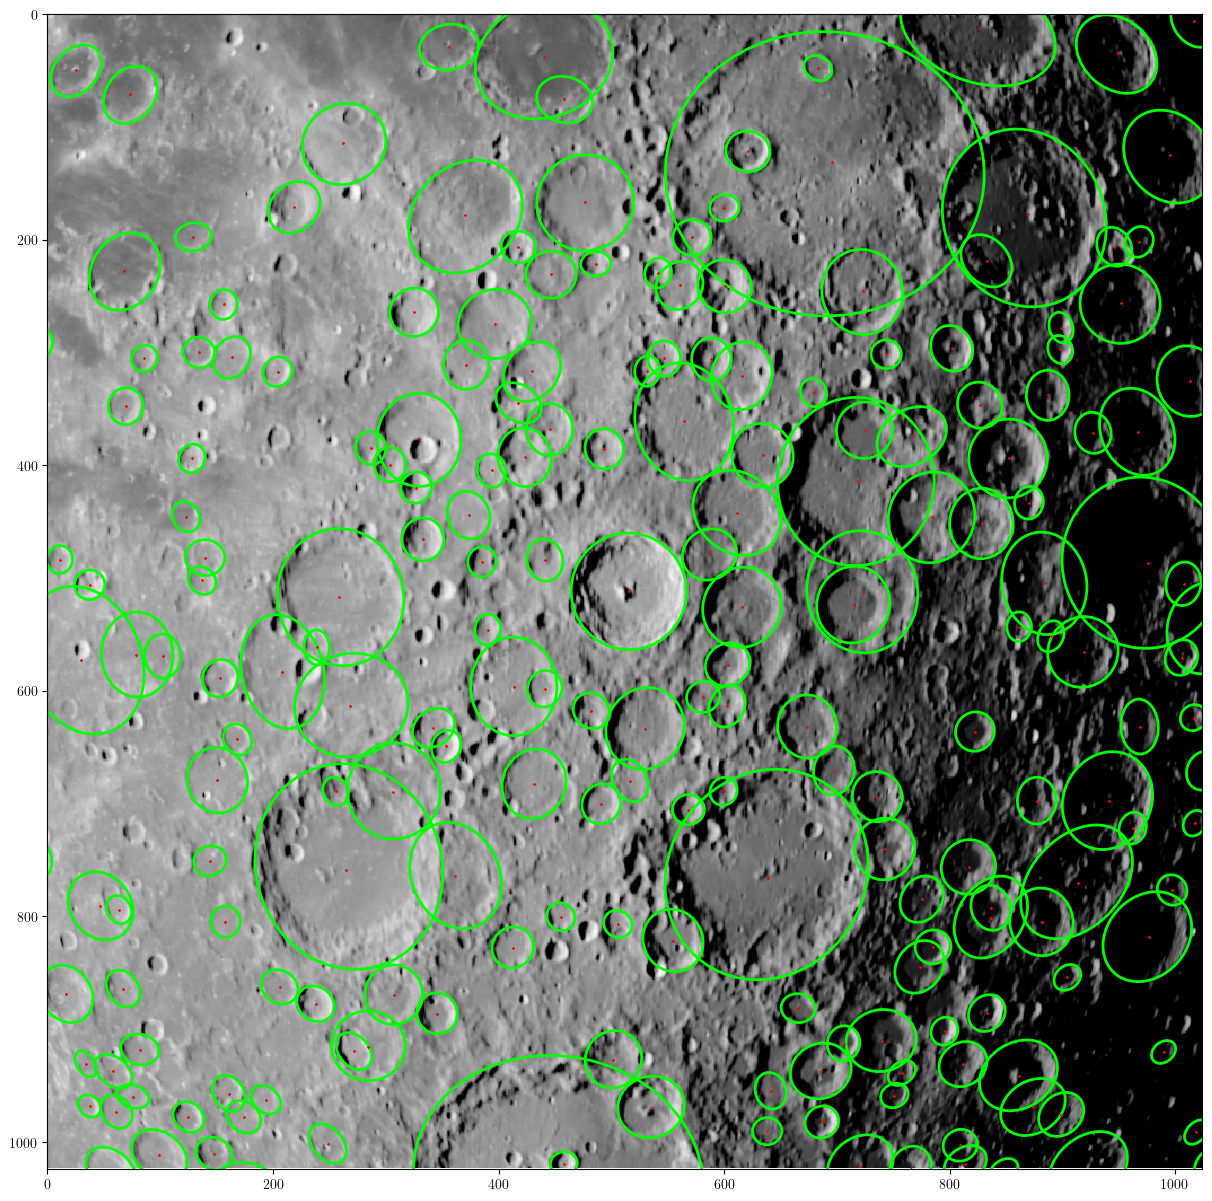

In [46]:
cam = Camera(resolution=N, fov=fov)
a_proj, b_proj = ellipse_axes(A_i)
psi_proj = ellipse_angle(A_i)
r_pix_proj = conic_center(A_i)


from matplotlib.collections import EllipseCollection

fig, ax = plt.subplots(figsize=(15, 15), subplot_kw={"aspect": "equal"})
ax.imshow(im, aspect="equal", interpolation="none", cmap="gray")
ec = EllipseCollection(
    a_proj,
    b_proj,
    np.degrees(psi_proj),
    units="xy",
    offsets=r_pix_proj,
    transOffset=ax.transData,
    facecolors="None",
    edgecolors="lime",
    linewidths=2,
)
ax.add_collection(ec)

ax.scatter(*project_crater_centers(p_Mi, fov, N, T_CM, r_M).T, c="r", s=1.2, marker="x")

ax.set_xlim(0, N[0])
ax.set_ylim(N[1], 0)

plt.show()
fig.savefig('../figures/ellipse_overlaid.png')

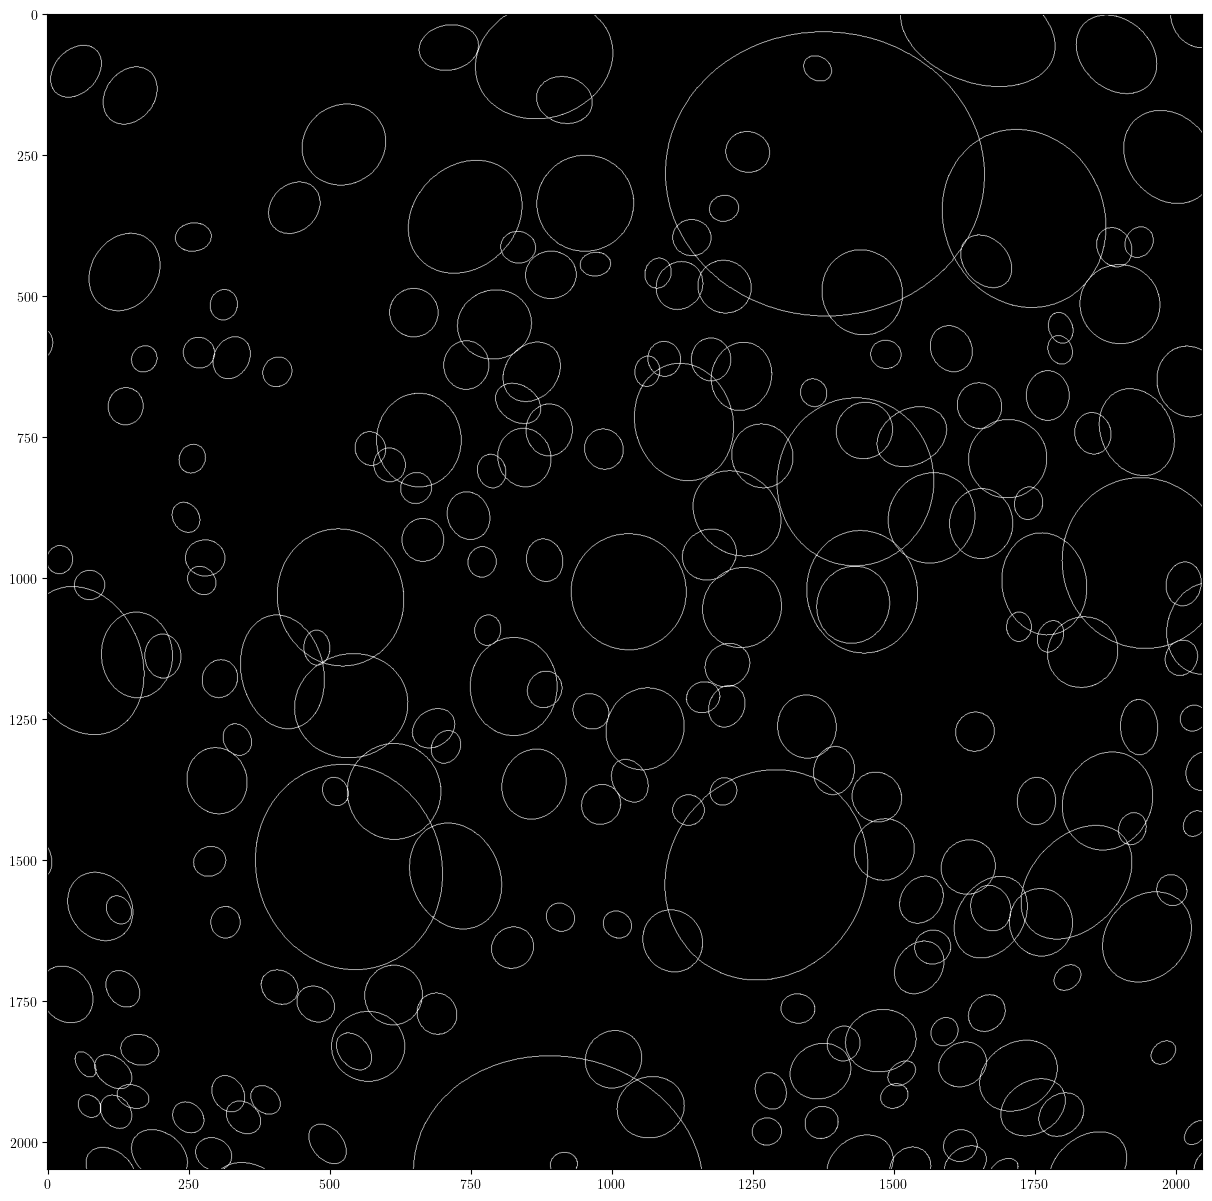

In [16]:
fig, ax = plt.subplots(figsize=(15, 15), subplot_kw={"aspect": "equal"})
ax.imshow(generate_mask(A_i, cam.resolution), cmap="Greys_r")